# Mathematics & Statistics for Machine Learning

A practical theory + Python notebook for the mathematical foundation needed for Machine Learning.

## Main sections
1. **Linear Algebra**
2. **Statistics & Data Analysis**
3. **Probability**
4. **Calculus & Optimization**
5. **How these topics connect to ML**

### Source alignment
The uploaded **Statistics.pdf** is used as the basis for the Statistics/Probability sections. Its progression includes:
- One-way and two-way tables
- Quantitative and qualitative variables
- Frequency and relative-frequency tables
- Bar, pie and line graphs
- Ogives, dot plots and histograms
- Central tendency
- Measures of spread
- IQR and outliers
- Five-number summary
- Mean, variance and standard deviation
- Density curves and skewness
- Z-scores
- Covariance
- Probability
- Permutations and combinations
- Addition rule
- Independent/dependent events
- Conditional probability
- Bayes theorem
- Hypothesis testing
- Type I and Type II errors
- Z-test, t-test, two-sample testing and chi-square testing

**Linear algebra and calculus are added as ML-oriented mathematical foundations. They are not presented as topics verified from the Statistics.pdf.**

> Goal: understand the mathematics conceptually, then see it in Python/NumPy/SciPy so that it becomes useful for ML rather than remaining only formula memorization.


# 0. Setup

Most examples use:
- `NumPy` → numerical computation and linear algebra
- `Pandas` → tables/data
- `Matplotlib` → visualization
- `SciPy` → statistical tests and distributions
- `SymPy` → symbolic calculus

If a package is missing in your environment, install it with:

```bash
pip install numpy pandas matplotlib scipy sympy scikit-learn
```


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import sympy as sp

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")


# 1. Linear Algebra for Machine Learning

Linear algebra gives us the language used to represent:
- datasets
- features
- model parameters
- transformations
- neural-network layers
- projections
- dimensionality reduction

The basic hierarchy is:

**Scalar → Vector → Matrix → Higher-dimensional Tensor**


## 1.1 Scalars

A scalar is a single number.

Examples:
- age = 21
- learning rate = 0.01
- temperature = 30

In Python:

```python
x = 5
learning_rate = 0.01
```

A scalar often represents one measurement or one model parameter.


In [53]:
x = 5
learning_rate = 0.01

print("x =", x)
print("learning_rate =", learning_rate)


x = 5
learning_rate = 0.01


## 1.2 Vectors

A vector is an ordered collection of numbers.

For a student:

**x = [age, height, weight, CGPA]**

Example:

x = [21, 170, 70, 7.34]

In ML, one row of a dataset can be represented as a feature vector.

### Important operations
- addition/subtraction
- scalar multiplication
- dot product
- magnitude/norm
- distance


In [54]:
x = np.array([21, 170, 70, 7.34])
y = np.array([20, 165, 65, 8.00])

print("x + y =", x + y)
print("2x =", 2 * x)
print("dot product =", np.dot(x, y))
print("L2 norm =", np.linalg.norm(x))


x + y = [ 41.   335.   135.    15.34]
2x = [ 42.   340.   140.    14.68]
dot product = 33078.72
L2 norm = 185.18875667815257


## 1.3 Dot Product

For

**a = [a₁, a₂, ..., aₙ]**

and

**b = [b₁, b₂, ..., bₙ]**

the dot product is:

**a · b = Σ aᵢbᵢ**

Example:

a = [1, 2, 3]

b = [4, 5, 6]

a · b = 1×4 + 2×5 + 3×6 = 32

### Why ML cares
Linear models repeatedly use expressions such as:

**ŷ = wᵀx + b**

which is a dot product plus a bias.


In [55]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

manual_dot = sum(ai * bi for ai, bi in zip(a, b))
numpy_dot = a @ b

print("Manual:", manual_dot)
print("NumPy :", numpy_dot)


Manual: 32
NumPy : 32


## 1.4 Norms and Distance

The most common vector norm is the **L2 norm**:

||x||₂ = √(x₁² + x₂² + ... + xₙ²)

Euclidean distance between x and y:

**d(x,y) = ||x-y||₂**

Other useful norm:

**L1 norm = Σ|xᵢ|**

### ML connection
Distance is central to:
- KNN
- K-means
- clustering
- nearest-neighbor methods

L1 regularization is associated with sparse solutions, while L2 regularization penalizes large parameter magnitudes.


In [56]:
x = np.array([1, 2, 3])
y = np.array([4, 6, 3])

l1 = np.linalg.norm(x, ord=1)
l2 = np.linalg.norm(x, ord=2)
distance = np.linalg.norm(x - y)

print("L1 norm:", l1)
print("L2 norm:", l2)
print("Euclidean distance:", distance)


L1 norm: 6.0
L2 norm: 3.7416573867739413
Euclidean distance: 5.0


## 1.5 Matrices

A matrix is a rectangular arrangement of numbers.

A dataset can naturally be represented as a matrix:

**X ∈ R^(n×d)**

where:
- n = number of observations/rows
- d = number of features/columns

Example:

X =
[[age₁, income₁],
 [age₂, income₂],
 [age₃, income₃]]

This representation is fundamental in ML.


In [57]:
X = np.array([
    [21, 25000],
    [25, 32000],
    [32, 48000],
    [40, 72000]
])

print("X =")
print(X)
print("Shape:", X.shape)


X =
[[   21 25000]
 [   25 32000]
 [   32 48000]
 [   40 72000]]
Shape: (4, 2)


## 1.6 Matrix Operations

Important operations:
- addition/subtraction
- scalar multiplication
- transpose
- matrix multiplication
- element-wise multiplication

### Matrix multiplication

If:

A is m×n and B is n×p,

then:

**AB is m×p**

In NumPy, use `A @ B`.

This operation appears everywhere in ML, especially linear regression and neural networks.


In [58]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A + B:")
print(A + B)

print("\nA @ B:")
print(A @ B)

print("\nA transpose:")
print(A.T)


A + B:
[[ 6  8]
 [10 12]]

A @ B:
[[19 22]
 [43 50]]

A transpose:
[[1 3]
 [2 4]]


## 1.7 Identity Matrix, Determinant and Inverse

The identity matrix I satisfies:

**AI = IA = A**

For a square matrix A, an inverse A⁻¹ satisfies:

**AA⁻¹ = I**

The inverse exists only when A is non-singular, equivalently when its determinant is non-zero.

### ML connection
Matrix inverses appear in mathematical derivations such as the closed-form solution of ordinary least squares:

**β = (XᵀX)⁻¹Xᵀy**

In numerical ML code, directly computing an inverse is often avoided when a solver can be used more stably.


In [59]:
A = np.array([[4, 7], [2, 6]], dtype=float)

print("det(A) =", np.linalg.det(A))
print("A^-1 =")
print(np.linalg.inv(A))
print("A @ A^-1 =")
print(A @ np.linalg.inv(A))


det(A) = 10.000000000000002
A^-1 =
[[ 0.6 -0.7]
 [-0.2  0.4]]
A @ A^-1 =
[[ 1.  0.]
 [-0.  1.]]


## 1.8 Eigenvalues and Eigenvectors

For a square matrix A:

**Av = λv**

where:
- v is an eigenvector
- λ is its corresponding eigenvalue

The transformation by A changes the length of an eigenvector but not its direction.

### ML connection
Eigenvalues/eigenvectors are important in:
- PCA
- covariance-matrix analysis
- spectral methods
- dimensionality reduction


In [60]:
A = np.array([
    [2, 1],
    [1, 2]
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:")
print(eigenvectors)


Eigenvalues: [3. 1.]
Eigenvectors:
[[ 0.707 -0.707]
 [ 0.707  0.707]]


## 1.9 Projection

Projection of vector a onto vector b:

**proj_b(a) = ((a·b)/(b·b)) b**

Projection is useful for understanding:
- least squares
- linear regression geometrically
- orthogonal decomposition
- dimensionality reduction


In [61]:
a = np.array([3, 2])
b = np.array([1, 0])

projection = (a @ b) / (b @ b) * b
print("Projection of a onto b:", projection)


Projection of a onto b: [3. 0.]


## 1.10 SVD — Singular Value Decomposition

A matrix can be decomposed as:

**A = UΣVᵀ**

SVD is useful for:
- dimensionality reduction
- compression
- noise reduction
- recommender systems
- solving least-squares problems

PCA can be implemented using SVD without explicitly computing the covariance matrix eigenvectors.


In [62]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
], dtype=float)

U, S, VT = np.linalg.svd(A)

print("U:")
print(U)
print("\nSingular values:")
print(S)
print("\nV^T:")
print(VT)


U:
[[ 0.386 -0.922]
 [ 0.922  0.386]]

Singular values:
[9.508 0.773]

V^T:
[[ 0.429  0.566  0.704]
 [ 0.806  0.112 -0.581]
 [ 0.408 -0.816  0.408]]


# 2. Statistics for Machine Learning

The uploaded Statistics.pdf begins with data tables and visualization and then moves into mathematical analysis of data.

The source uses the distinction:
- **Quantitative variables** → numerical measurements such as age/salary/height
- **Qualitative variables** → categorical information such as gender/genre

It also introduces one-way and two-way tables before moving to distributions and numerical summaries.


## 2.1 Population vs Sample

**Population:** the complete group of interest.

**Sample:** a subset observed from that population.

Example:
- Population → all students in a university
- Sample → 200 students selected for analysis

This distinction becomes important when estimating population quantities from a sample and when performing hypothesis tests.


## 2.2 One-Way Table

A one-way table summarizes one variable.

Example:

| Fruit | Count |
|---|---:|
| Apple | 6 |
| Banana | 4 |
| Kiwi | 2 |
| Mango | 2 |

The uploaded PDF uses this type of frequency table as the basis for bar and pie charts.


Apple     6
Banana    4
Kiwi      2
Mango     2
Name: count, dtype: int64


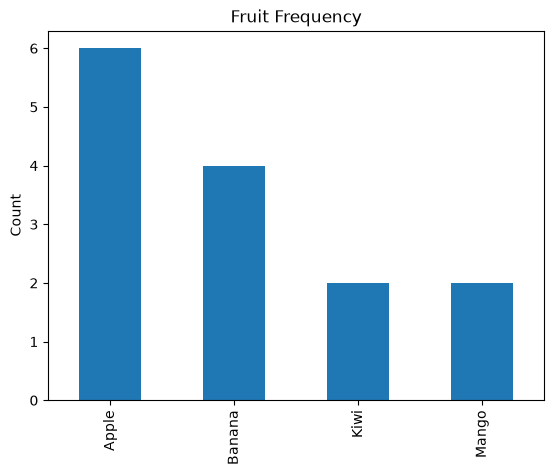

In [63]:
fruit = pd.Series([
    "Apple", "Banana", "Apple", "Apple", "Banana", "Kiwi",
    "Apple", "Kiwi", "Apple", "Mango", "Mango", "Apple", "Banana", "Banana"
])

freq = fruit.value_counts()
print(freq)

freq.plot(kind="bar", title="Fruit Frequency")
plt.ylabel("Count")
plt.show()


## 2.3 Relative Frequency

Relative frequency:

**Relative frequency = frequency / total frequency**

Percentage:

**Percentage = relative frequency × 100**

This is the idea used in the PDF's relative-frequency examples and pie-chart percentages.


In [64]:
relative_frequency = freq / freq.sum()
percentage = relative_frequency * 100

print("Relative frequency:")
print(relative_frequency)

print("\nPercentage:")
print(percentage)


Relative frequency:
Apple    0.429
Banana   0.286
Kiwi     0.143
Mango    0.143
Name: count, dtype: float64

Percentage:
Apple    42.857
Banana   28.571
Kiwi     14.286
Mango    14.286
Name: count, dtype: float64


## 2.4 Two-Way Table

A two-way table studies two variables simultaneously.

The PDF's example organizes revenue by **month × year**, so the value depends on both the row and column.

In Python, `pd.crosstab()` is useful for frequency-style two-way tables and `pivot_table()` for aggregated numerical values.


In [65]:
data = pd.DataFrame({
    "Year": [2022, 2022, 2023, 2023, 2023, 2022],
    "Month": ["Jan", "Feb", "Jan", "Feb", "Mar", "Mar"],
    "Revenue": [50, 70, 60, 80, 90, 75]
})

pivot = data.pivot_table(
    index="Month",
    columns="Year",
    values="Revenue",
    aggfunc="sum"
)

display(pivot)


Year,2022,2023
Month,,
Feb,70,80
Jan,50,60
Mar,75,90


## 2.5 Visualizations

The uploaded PDF covers:
- Bar graph → categorical frequency comparison
- Pie chart → proportions/percentage composition
- Line graph → trends over an ordered/continuous sequence
- Ogive → cumulative frequency
- Dot plot → values represented as stacked dots
- Histogram → numerical data grouped into bins

### Bar chart vs histogram
A bar chart is generally used for categories; a histogram groups numerical observations into intervals/bins.


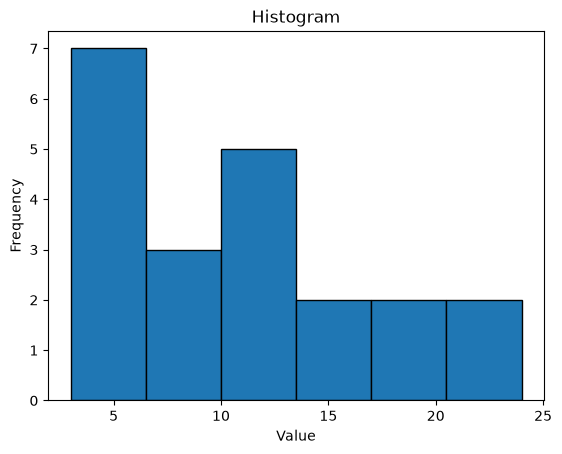

In [66]:
values = [3, 4, 4, 5, 5, 6, 6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 18, 20, 21, 24]

plt.hist(values, bins=6, edgecolor="black")
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


## 2.6 Mean

Arithmetic mean:

**x̄ = (x₁ + x₂ + ... + xₙ) / n**

It represents the average of the observations.

Python:
`np.mean(x)`

Mean is sensitive to extreme values.


In [67]:
x = np.array([1, 2, 3, 4, 5])

print("Mean:", np.mean(x))


Mean: 3.0


## 2.7 Median

The median is the middle value after sorting.

If n is odd:

**Median = x[(n+1)/2]** (1-based position)

If n is even, the median is the average of the two middle values.

Median is often more robust than mean when a distribution contains strong outliers or skewness.


In [68]:
x = np.array([1, 2, 3, 4, 100])

print("Mean:", np.mean(x))
print("Median:", np.median(x))


Mean: 22.0
Median: 3.0


## 2.8 Mode

The mode is the most frequently occurring value.

It is especially useful for categorical data.

Example:

[2, 2, 2, 3, 4] → mode = 2


In [69]:
x = pd.Series([2, 2, 2, 3, 4])
print("Mode:", x.mode().tolist())


Mode: [2]


## 2.9 Mean vs Median vs Mode

| Measure | Meaning | Sensitive to outliers? |
|---|---|---|
| Mean | Arithmetic average | Yes |
| Median | Middle ordered value | Much less |
| Mode | Most frequent value | Generally not affected by numerical magnitude |

The PDF emphasizes choosing central-tendency measures according to the distribution; for skewed data it notes that median can be preferable to mean.


## 2.10 Range

Range:

**Range = Maximum − Minimum**

It is the simplest measure of spread.

Example:
[3, 5, 8, 10] → range = 10 − 3 = 7


In [70]:
x = np.array([3, 5, 8, 10])
print("Range:", np.max(x) - np.min(x))


Range: 7


## 2.11 Quartiles and Percentiles

Percentiles divide ordered data by percentage position.

Important quartiles:
- Q1 = 25th percentile
- Q2 = 50th percentile = median
- Q3 = 75th percentile

The PDF uses quartiles heavily when explaining IQR and outlier detection.


In [71]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

Q1 = np.percentile(x, 25)
Q2 = np.percentile(x, 50)
Q3 = np.percentile(x, 75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)


Q1: 3.25
Q2: 5.5
Q3: 7.75


## 2.12 IQR — Interquartile Range

**IQR = Q3 − Q1**

It measures the spread of the middle 50% of the data.

A common outlier rule:

**Lower fence = Q1 − 1.5 × IQR**

**Upper fence = Q3 + 1.5 × IQR**

Values outside these fences are flagged as potential outliers.

The PDF explicitly uses this method in its outlier section.


In [72]:
x = np.array([1, 1, 2, 2, 3, 4, 5, 5, 6, 6, 7, 8, 9, 9, 10, 10, 11, 13, 13, 14, 15, 101])

Q1 = np.percentile(x, 25)
Q3 = np.percentile(x, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = x[(x < lower) | (x > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower)
print("Upper fence:", upper)
print("Potential outliers:", outliers)


Q1: 4.25
Q3: 10.75
IQR: 6.5
Lower fence: -5.5
Upper fence: 20.5
Potential outliers: [101]


## 2.13 Five-Number Summary

The five-number summary consists of:

1. Minimum
2. Q1
3. Median
4. Q3
5. Maximum

It gives a compact description of location and spread and is closely related to the boxplot.


In [73]:
x = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 15])

five_number = {
    "min": np.min(x),
    "Q1": np.percentile(x, 25),
    "median": np.median(x),
    "Q3": np.percentile(x, 75),
    "max": np.max(x)
}
print(five_number)


{'min': np.int64(3), 'Q1': np.float64(5.25), 'median': np.float64(7.5), 'Q3': np.float64(9.75), 'max': np.int64(15)}


## 2.14 Variance

Variance measures average squared deviation from the mean.

Population variance:

**σ² = Σ(xᵢ − μ)² / N**

Sample variance:

**s² = Σ(xᵢ − x̄)² / (n − 1)**

The denominator differs because sample variance uses the common `n−1` correction for estimating population variability.


In [74]:
x = np.array([1, 2, 3, 4, 5])

population_variance = np.var(x, ddof=0)
sample_variance = np.var(x, ddof=1)

print("Population variance:", population_variance)
print("Sample variance:", sample_variance)


Population variance: 2.0
Sample variance: 2.5


## 2.15 Standard Deviation

Standard deviation is the square root of variance.

**σ = √σ²**

**s = √s²**

Because it is expressed in the same units as the original variable, it is often easier to interpret than variance.


In [75]:
print("Population std:", np.std(x, ddof=0))
print("Sample std:", np.std(x, ddof=1))


Population std: 1.4142135623730951
Sample std: 1.5811388300841898


## 2.16 Density Curve and Skewness

The PDF introduces density curves and discusses skewed distributions.

General intuition:
- Symmetric distribution → mean and median can be close.
- Right-skewed distribution → long tail to the right; median can be more representative of the center.
- Left-skewed distribution → long tail to the left.

For spread in strongly skewed data, the PDF points toward robust measures such as IQR instead of relying only on standard deviation.


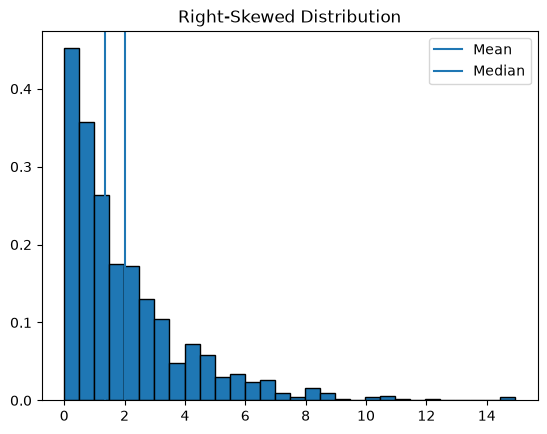

In [76]:
rng = np.random.default_rng(42)
right_skewed = rng.exponential(scale=2, size=1000)

plt.hist(right_skewed, bins=30, density=True, edgecolor="black")
plt.axvline(np.mean(right_skewed), label="Mean")
plt.axvline(np.median(right_skewed), label="Median")
plt.title("Right-Skewed Distribution")
plt.legend()
plt.show()


## 2.17 Z-Score

A z-score tells how many standard deviations an observation is from the mean.

**z = (x − μ) / σ**

Interpretation:
- z = 0 → at the mean
- z = +1 → one standard deviation above the mean
- z = −2 → two standard deviations below the mean

Z-scores are useful for standardization and identifying unusually distant observations under suitable assumptions.


In [77]:
x = 85
mean = 70
std = 10

z = (x - mean) / std
print("Z-score:", z)


Z-score: 1.5


## 2.18 Covariance

Covariance describes how two variables change together.

- Positive covariance → they tend to increase together.
- Negative covariance → one tends to increase when the other decreases.
- Near zero → little linear co-movement, although nonlinear relationships may still exist.

The PDF uses examples such as age and salary for positive covariance and time/rank for negative covariance.


In [78]:
age = np.array([21, 22, 23, 24, 25])
salary = np.array([26, 30, 34, 40, 45])

cov_matrix = np.cov(age, salary, ddof=1)
print(cov_matrix)
print("Covariance(age, salary):", cov_matrix[0, 1])


[[ 2.5 12. ]
 [12.  58. ]]
Covariance(age, salary): 12.0


## 2.19 Correlation

Correlation standardizes covariance:

**r = Cov(X,Y) / (σₓ σᵧ)**

For Pearson correlation:
- r ≈ +1 → strong positive linear relationship
- r ≈ −1 → strong negative linear relationship
- r ≈ 0 → weak/no linear relationship

Correlation measures association, not causation.


In [79]:
corr = np.corrcoef(age, salary)[0, 1]
print("Correlation:", corr)


Correlation: 0.9965457582448796


# 3. Probability

The Statistics.pdf section moves from descriptive statistics into probability and includes permutations/combinations, the addition rule, independent/dependent events, conditional probability and Bayes theorem.


## 3.1 Basic Probability

For equally likely outcomes:

**P(A) = Number of favorable outcomes / Total number of outcomes**

Probability lies between 0 and 1.

- 0 → impossible
- 1 → certain

Example: fair coin

P(Head) = 1/2


In [80]:
favorable = 1
total = 2
print("P(Head) =", favorable / total)


P(Head) = 0.5


## 3.2 Sample Space

The sample space contains all possible outcomes.

Two coin flips:

S = {HH, HT, TH, TT}

There are four equally likely outcomes.


In [81]:
sample_space = ["HH", "HT", "TH", "TT"]
print(sample_space)
print("Number of outcomes:", len(sample_space))


['HH', 'HT', 'TH', 'TT']
Number of outcomes: 4


## 3.3 Permutations and Combinations

### Permutation
Order matters.

**nPᵣ = n! / (n−r)!**

### Combination
Order does not matter.

**nCᵣ = n! / [r!(n−r)!]**

ML connection: counting helps build intuition for probability spaces and combinatorial models.


In [82]:
from math import factorial

n, r = 5, 2

permutation = factorial(n) // factorial(n-r)
combination = factorial(n) // (factorial(r) * factorial(n-r))

print("5P2 =", permutation)
print("5C2 =", combination)


5P2 = 20
5C2 = 10


## 3.4 Addition Rule

General rule:

**P(A ∪ B) = P(A) + P(B) − P(A ∩ B)**

If A and B are mutually exclusive, then:

**P(A ∪ B) = P(A) + P(B)**

The PDF demonstrates the addition rule using coin-flip examples.


In [83]:
# Two events:
P_A = 0.4
P_B = 0.5
P_A_and_B = 0.2

P_A_or_B = P_A + P_B - P_A_and_B
print("P(A or B) =", P_A_or_B)


P(A or B) = 0.7


## 3.5 Independent Events

Events A and B are independent when knowing A occurred does not change the probability of B.

For independent events:

**P(A ∩ B) = P(A)P(B)**

Example: repeated fair coin flips.


In [84]:
P_H1 = 0.5
P_H2 = 0.5

print("P(two heads) =", P_H1 * P_H2)


P(two heads) = 0.25


## 3.6 Dependent Events

If the first event changes the probability of the second event, the events are dependent.

General multiplication rule:

**P(A ∩ B) = P(A)P(B|A)**

The PDF uses drawing balls without replacement as its intuition for dependent events.


In [85]:
# 3 white + 2 red, draw 2 whites without replacement
P_first_white = 3 / 5
P_second_white_given_first = 2 / 4

P_two_white = P_first_white * P_second_white_given_first
print("P(two white) =", P_two_white)


P(two white) = 0.3


## 3.7 Conditional Probability

Conditional probability:

**P(A|B) = P(A ∩ B) / P(B)**, when P(B) > 0.

Read `P(A|B)` as:

> probability of A given that B has occurred.

Conditional probability is one of the most important bridges between probability and ML.


In [86]:
P_A_and_B = 0.15
P_B = 0.30

P_A_given_B = P_A_and_B / P_B
print("P(A|B) =", P_A_given_B)


P(A|B) = 0.5


## 3.8 Bayes Theorem

Bayes theorem:

**P(A|B) = P(B|A)P(A) / P(B)**

It allows us to reverse a conditional relationship.

### ML connection
Bayesian reasoning appears in:
- Naive Bayes classifiers
- probabilistic inference
- medical diagnosis
- spam classification
- belief updating


In [87]:
# Example
P_A = 0.01
P_B_given_A = 0.90
P_B = 0.10

P_A_given_B = (P_B_given_A * P_A) / P_B
print("P(A|B) =", P_A_given_B)


P(A|B) = 0.09000000000000001


## 3.9 Random Variables and Distributions

A random variable maps outcomes to numerical values.

### Discrete
Countable values:
- number of heads
- number of defective items

### Continuous
Can take values over an interval:
- height
- weight
- temperature

Useful distributions for ML:
- Bernoulli
- Binomial
- Normal/Gaussian
- Uniform
- Poisson

The Statistics.pdf focuses on the probability rules and statistical analysis listed above; these distribution concepts are added as standard ML probability foundations.


In [88]:
# Bernoulli and Binomial examples using SciPy
p = 0.5

print("P(X=1) for Bernoulli:", stats.bernoulli.pmf(1, p))
print("P(X=3) for Binomial(n=10,p=.5):",
      stats.binom.pmf(3, n=10, p=p))


P(X=1) for Bernoulli: 0.5
P(X=3) for Binomial(n=10,p=.5): 0.1171875


## 3.10 Normal Distribution

For a normal distribution:

**X ~ N(μ, σ²)**

It is symmetric around μ.

Standardization converts X to a standard normal variable:

**Z = (X−μ)/σ**

The normal distribution is fundamental in statistics, confidence intervals and many ML assumptions.


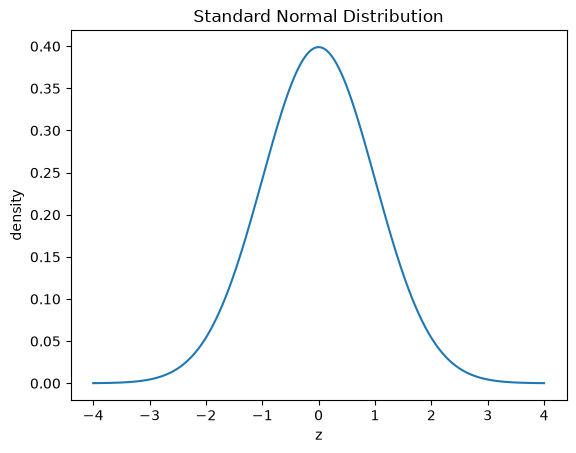

In [89]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf)
plt.title("Standard Normal Distribution")
plt.xlabel("z")
plt.ylabel("density")
plt.show()


# 4. Statistical Inference & Hypothesis Testing

The PDF introduces hypothesis testing through the example of checking whether a coin is fair.

The central structure is:

1. Define hypotheses
2. Choose a test/statistic
3. Calculate the test statistic
4. Obtain a p-value or compare with a critical region
5. Make a decision using a chosen significance level


## 4.1 Null and Alternative Hypotheses

**H₀ (null hypothesis):** baseline/default claim.

**H₁ (alternative hypothesis):** competing claim.

Example for a coin:

H₀: p = 0.5

H₁: p ≠ 0.5

A hypothesis test asks whether the observed evidence is sufficiently inconsistent with H₀.


## 4.2 Type I and Type II Errors

| Reality / Decision | Reject H₀ | Do not reject H₀ |
|---|---|---|
| H₀ true | Type I error | Correct |
| H₀ false | Correct | Type II error |

- **Type I error (α):** reject a true H₀.
- **Type II error (β):** fail to reject a false H₀.

The PDF explicitly introduces these two error types.


## 4.3 Significance Level and p-value

A common significance level is:

**α = 0.05**

The p-value measures how compatible the observed result is with H₀ under the test assumptions.

A common decision rule is:
- p-value < α → reject H₀
- p-value ≥ α → do not reject H₀

This does **not** mean that the p-value is the probability that H₀ is true.


## 4.4 Z-Test

The PDF presents a z-test for situations where the population standard deviation is known (and discusses larger-sample usage).

One-sample z statistic:

**z = (x̄ − μ₀) / (σ / √n)**

where:
- x̄ = sample mean
- μ₀ = hypothesized population mean
- σ = population standard deviation
- n = sample size


In [90]:
sample_mean = 52
population_mean = 50
population_std = 8
n = 64

z = (sample_mean - population_mean) / (population_std / np.sqrt(n))
p_value_two_sided = 2 * (1 - stats.norm.cdf(abs(z)))

print("z =", z)
print("two-sided p-value =", p_value_two_sided)


z = 2.0
two-sided p-value = 0.04550026389635842


## 4.5 One-Sample t-Test

The PDF introduces the t-test when the population standard deviation is unknown.

For a one-sample t-test:

**t = (x̄ − μ₀) / (s / √n)**

Degrees of freedom:

**df = n − 1**

The t distribution has heavier tails than the standard normal distribution, especially for small samples.


In [91]:
sample = np.array([52, 49, 51, 55, 48, 50, 54, 53, 47, 51])

t_stat, p_value = stats.ttest_1samp(sample, popmean=50)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 1.224744871391589
p-value: 0.25175947606701277


## 4.6 Two-Sample Test

The PDF gives a two-treatment example comparing recovery times.

Typical question:

> Is there evidence that the population means of the two groups differ?

For independent samples, a t-test can compare their means. Welch's t-test is often preferred when equal population variances should not be assumed.


In [92]:
treatment_A = np.array([7, 8, 9, 8, 7, 10, 8, 9, 7, 8])
treatment_B = np.array([9, 11, 10, 12, 9, 10, 11, 9, 10, 12])

t_stat, p_value = stats.ttest_ind(
    treatment_A,
    treatment_B,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -4.554432691659541
p-value: 0.0002592731129419968


## 4.7 Chi-Square Test

The PDF ends with a chi-square test.

For a contingency table, the chi-square test can examine whether two categorical variables are associated.

The statistic compares observed and expected frequencies:

**χ² = Σ (O−E)²/E**

where:
- O = observed frequency
- E = expected frequency


In [93]:
# Example contingency table
table = np.array([
    [30, 20],
    [10, 40]
])

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)


Chi-square statistic: 15.041666666666668
p-value: 0.00010516355403363114
degrees of freedom: 1
Expected frequencies:
[[20. 30.]
 [20. 30.]]


# 5. Calculus for Machine Learning

Calculus is mainly needed in ML for **optimization**.

The central idea:

> A model has parameters. We define a loss function. Calculus tells us how the loss changes when parameters change. Optimization uses that information to reduce the loss.

Key topics:
- functions
- limits
- derivatives
- partial derivatives
- gradients
- chain rule
- directional intuition
- optimization
- integration


## 5.1 Function

A function maps input to output:

**y = f(x)**

Example:

**f(x) = x²**

In ML, a model can be viewed as a function:

**ŷ = f(X; θ)**

where θ represents learnable parameters.


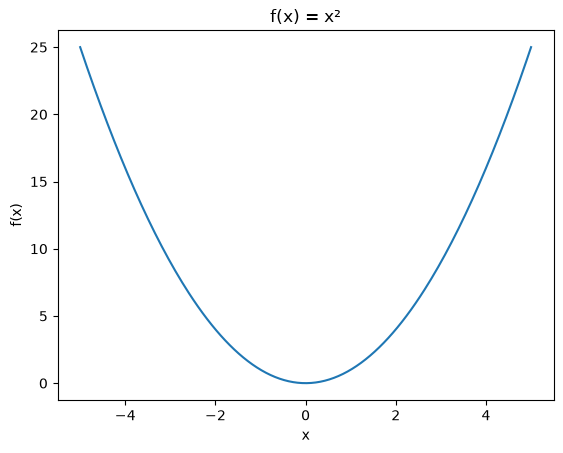

In [94]:
def f(x):
    return x**2

x = np.linspace(-5, 5, 200)
plt.plot(x, f(x))
plt.title("f(x) = x²")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


## 5.2 Derivative

The derivative measures the rate at which a function changes.

For:

**f(x) = x²**

the derivative is:

**f'(x) = 2x**

Interpretation:
- positive derivative → function increasing locally
- negative derivative → function decreasing locally
- zero derivative → stationary point (may be minimum, maximum or saddle in higher dimensions)


In [95]:
x = sp.symbols("x")
f = x**2

print("f(x) =", f)
print("f'(x) =", sp.diff(f, x))


f(x) = x**2
f'(x) = 2*x


## 5.3 Partial Derivatives

For a multivariable function:

**f(x,y)**

we can differentiate with respect to one variable while treating the others as constants.

Example:

**f(x,y) = x² + 3xy + y²**

∂f/∂x = 2x + 3y

∂f/∂y = 3x + 2y


In [96]:
x, y = sp.symbols("x y")
f = x**2 + 3*x*y + y**2

print("∂f/∂x =", sp.diff(f, x))
print("∂f/∂y =", sp.diff(f, y))


∂f/∂x = 2*x + 3*y
∂f/∂y = 3*x + 2*y


## 5.4 Gradient

The gradient collects partial derivatives into a vector:

**∇f = [∂f/∂x₁, ∂f/∂x₂, ..., ∂f/∂xₙ]**

The gradient points in the direction of greatest local increase of the function.

Therefore, **−∇f** points toward the direction of greatest local decrease.

### ML connection
Gradient descent updates parameters in the negative-gradient direction.


In [97]:
x, y = sp.symbols("x y")
f = x**2 + y**2

gradient = [sp.diff(f, x), sp.diff(f, y)]
print("Gradient:", gradient)


Gradient: [2*x, 2*y]


## 5.5 Chain Rule

For a composition:

**y = f(g(x))**

the chain rule is:

**dy/dx = f'(g(x)) · g'(x)**

This becomes extremely important in neural networks because a network is a composition of many functions.

**Backpropagation is essentially efficient application of the chain rule to compute gradients through a computational graph.**


In [98]:
x = sp.symbols("x")

g = x**2
f = sp.sin(g)

derivative = sp.diff(f, x)

print("f(g(x)) =", f)
print("Derivative =", derivative)


f(g(x)) = sin(x**2)
Derivative = 2*x*cos(x**2)


## 5.6 Derivative of Common Functions

Useful derivatives to remember:

- d(c)/dx = 0
- d(xⁿ)/dx = n xⁿ⁻¹
- d(eˣ)/dx = eˣ
- d(ln x)/dx = 1/x
- d(sin x)/dx = cos x
- d(cos x)/dx = −sin x

These appear frequently when deriving ML loss functions and activation functions.


## 5.7 Integration

Integration can be viewed as accumulation/area under a curve.

For a function f(x):

**∫ f(x) dx**

Definite integral:

**∫ₐᵇ f(x) dx**

Integration is less central than differentiation for basic model training, but it is important in probability because a continuous probability density integrates to 1.


In [99]:
x = sp.symbols("x")
f = x**2

indefinite = sp.integrate(f, x)
definite = sp.integrate(f, (x, 0, 2))

print("Indefinite integral:", indefinite)
print("Integral from 0 to 2:", definite)


Indefinite integral: x**3/3
Integral from 0 to 2: 8/3


## 5.8 Loss Functions

A loss function measures how wrong a prediction is.

### Mean Squared Error

For regression:

**MSE = (1/n) Σ(yᵢ − ŷᵢ)²**

### Mean Absolute Error

**MAE = (1/n) Σ|yᵢ − ŷᵢ|**

The learning algorithm tries to find parameters that minimize an appropriate loss.


In [100]:
y_true = np.array([3, 5, 7, 9])
y_pred = np.array([2, 6, 6, 10])

mse = np.mean((y_true - y_pred)**2)
mae = np.mean(np.abs(y_true - y_pred))

print("MSE:", mse)
print("MAE:", mae)


MSE: 1.0
MAE: 1.0


## 5.9 Gradient Descent

For parameter θ and learning rate η:

**θ ← θ − η ∇J(θ)**

where J(θ) is the loss.

### Intuition
1. Start with a parameter value.
2. Calculate the gradient.
3. Move opposite to the gradient.
4. Repeat.
5. Stop when the loss is sufficiently small or convergence criteria are met.

The learning rate controls the step size.


Final x: 0.00011417981541647683


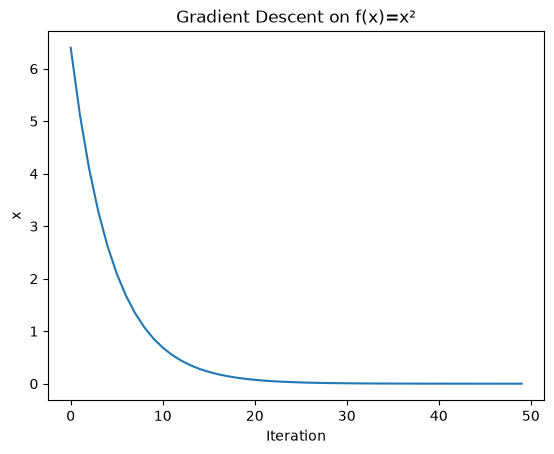

In [101]:
# Simple gradient descent for f(x) = x^2
x = 8.0
learning_rate = 0.1

history = []

for _ in range(50):
    gradient = 2 * x
    x = x - learning_rate * gradient
    history.append(x)

print("Final x:", x)

plt.plot(history)
plt.title("Gradient Descent on f(x)=x²")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()


## 5.10 Linear Regression as a Math Example

A simple linear model:

**ŷ = wx + b**

Mean squared error:

**J(w,b) = (1/n) Σ(yᵢ − (wxᵢ+b))²**

The derivatives tell us how to change w and b to reduce the loss.

For one variable:

**∂J/∂w = −(2/n) Σ xᵢ(yᵢ − ŷᵢ)**

**∂J/∂b = −(2/n) Σ (yᵢ − ŷᵢ)**

This connects:
**linear algebra + calculus + statistics → ML model training.**


In [102]:
# Manual gradient descent for y ≈ wx + b
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)

w, b = 0.0, 0.0
lr = 0.01

for _ in range(2000):
    y_pred = w * X + b

    dw = (-2 / len(X)) * np.sum(X * (y - y_pred))
    db = (-2 / len(X)) * np.sum(y - y_pred)

    w -= lr * dw
    b -= lr * db

print("Learned w:", w)
print("Learned b:", b)
print("Predictions:", w * X + b)


Learned w: 2.0001312429307236
Learned b: 0.9995261713769317
Predictions: [ 3.  5.  7.  9. 11.]


# 6. How the Four Areas Connect to ML

## Linear Algebra
Used to represent and transform data:
- vectors = individual observations/features
- matrices = datasets/parameters
- dot products = linear models
- matrix multiplication = neural-network layers
- eigenvectors/SVD = PCA and dimensionality reduction

## Statistics
Used to understand data:
- mean/median/mode
- variance/std
- quartiles/IQR
- distributions
- covariance/correlation
- descriptive summaries

## Probability
Used to reason under uncertainty:
- conditional probability
- Bayes theorem
- probability distributions
- likelihood
- probabilistic models

## Calculus
Used to train models:
- derivatives
- partial derivatives
- gradients
- chain rule
- optimization
- gradient descent


# 7. ML Math Cheat Sheet

### Linear Algebra
- Dot product: `a @ b`
- Matrix multiplication: `A @ B`
- Transpose: `A.T`
- Norm: `np.linalg.norm(x)`
- Inverse: `np.linalg.inv(A)`
- Eigen: `np.linalg.eig(A)`
- SVD: `np.linalg.svd(A)`

### Statistics
- Mean: `np.mean(x)`
- Median: `np.median(x)`
- Variance: `np.var(x, ddof=...)`
- Standard deviation: `np.std(x, ddof=...)`
- Percentile: `np.percentile(x, p)`
- Covariance: `np.cov(x, y)`
- Correlation: `np.corrcoef(x, y)`

### Probability
- Addition: P(A∪B) = P(A)+P(B)−P(A∩B)
- Multiplication: P(A∩B)=P(A)P(B|A)
- Conditional: P(A|B)=P(A∩B)/P(B)
- Bayes: P(A|B)=P(B|A)P(A)/P(B)

### Calculus
- Derivative → rate of change
- Partial derivative → change with respect to one variable
- Gradient → vector of partial derivatives
- Chain rule → derivative of compositions
- Gradient descent → θ ← θ − η∇J(θ)


# 8. Recommended Learning Order for ML

If your goal is ML rather than pure mathematics, learn in this order:

### Phase 1 — Statistics basics
1. Data types
2. Tables and frequency
3. Visualization
4. Mean / median / mode
5. Range / quartiles / percentiles
6. IQR / outliers
7. Variance / standard deviation
8. Z-score
9. Covariance / correlation

### Phase 2 — Probability
10. Sample space and events
11. Permutation / combination
12. Addition and multiplication rules
13. Independent/dependent events
14. Conditional probability
15. Bayes theorem
16. Random variables and distributions

### Phase 3 — Linear Algebra
17. Vectors
18. Dot product
19. Norms and distance
20. Matrices
21. Matrix multiplication
22. Transpose
23. Inverse / determinant
24. Eigenvalues/eigenvectors
25. SVD and projection

### Phase 4 — Calculus
26. Functions
27. Derivatives
28. Partial derivatives
29. Gradient
30. Chain rule
31. Optimization
32. Gradient descent

### Phase 5 — Apply immediately
Use the concepts while learning:
- Linear Regression
- Logistic Regression
- KNN
- Naive Bayes
- PCA
- SVM
- Neural Networks

This order prevents mathematics from becoming disconnected formula memorization.


# 9. Final Mental Model

Think of ML mathematics like this:

**Statistics** → What does the data tell us?

**Probability** → How uncertain are we?

**Linear Algebra** → How do we represent and transform the data?

**Calculus** → How do we change model parameters to reduce error?

Then:

**Data → EDA → Mathematical representation → Model → Loss → Gradients/optimization → Evaluation**

This is the mathematical foundation behind the ML workflow you studied in the previous notebook.


## Source note

The Statistics.pdf is an image-based 150+ page document; its visible sections were inspected through rendered pages. The statistics/probability coverage above follows its sequence and terminology, including the visualization material at the beginning and the later sections on central tendency, spread, outliers, five-number summary, variance/standard deviation, density curves, z-scores, covariance, probability and hypothesis testing.

Linear algebra and calculus are intentionally marked as **ML-oriented additions**, because those topics are not established by the visible Statistics.pdf material.
